# Options Paper Analysis

**Option-Market Depth, Rate Risk, and the Limits of Hedgeability in Fixed-Income ETFs**

Sections:
1. Load Data (+ Build Panel)
2. Universe Coverage
3. Rate-Space Exposures and Hedge Capacity
4. Empirical Rate-Duration Proxy
5. Duration-Scaled Greek Exposure (Robustness)
6. Hedgeability Scores
7. Convexity Capacity and Rate Carry
8. IV-Realized Variance Gap (Appendix Diagnostic)
9. Predictive Regressions
10. Spec 0 Robustness: Within vs. Between
11. Paper Artifacts (capacity accounting, book anatomy, validation)


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src import config as cfg
from src.data.options_universe import UNIVERSE, BUCKET_ORDER, ticker_bucket
from src.features.options_features import (
    add_duration_exposure_features,
    add_duration_normalized_hedgeability,
    add_latest_duration_exposure_to_panel,
    add_rate_duration_to_panel,
    compute_hedgeability_score,
    compute_vrp,
    estimate_rolling_rate_duration,
    summarize_duration_exposure,
    summarize_roll_cost_by_regime,
)
from src.analysis.regression_utils import cgm_summary

cfg.ensure_options_dirs()
sns.set_theme(style="ticks", palette="deep", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

# Duration-bucket palette used by every figure (seaborn "deep")
colors = {"short": "#4C72B0", "intermediate": "#DD8452",
          "long": "#55A868", "credit": "#C44E52", "other": "#937860"}

---
## 1. Load Data


In [2]:
# ── Screen outputs (read-only) ────────────────────────────────────────────
# Produced by scripts/02_concat_screen.py from the chain cache.
# Chain fetching itself: scripts/04_build_options_panel.py --repull.
# Full pipeline: python scripts/reproduce.py  (see REPRODUCING.md)
ticker_summary_built = pd.read_csv(cfg.TICKER_SUMMARY_CSV)
liquid_tickers = ticker_summary_built[ticker_summary_built["liquid"]]["ticker"].tolist()
print(f"Liquid tickers ({len(liquid_tickers)}): {sorted(liquid_tickers)}")
display(ticker_summary_built.sort_values("median_liq_score", ascending=False).round(3))

Liquid tickers (8): ['EDV', 'EMB', 'IEF', 'LQD', 'TIP', 'TLT', 'VCLT', 'ZROZ']


,ticker,dates_screened,mean_pass_rate,median_iv,median_dollar_vega,median_dollar_gamma,median_dollar_delta,median_sqrt_oi_notional,median_cost_adj_depth,median_balanced_depth,median_liq_score,liquid
30,TLT,20,0.4610,0.1610,0.1320,0.0310,-19.5270,12143.3160,11025.1550,5817.2490,5518.0040,True
20,LQD,21,0.3670,0.1180,0.1070,0.0450,-55.0990,5370.1500,4972.3610,2375.4960,2182.7330,True
16,IEF,22,0.3270,0.0860,0.1030,0.0540,-34.7350,3094.0890,2862.0870,1288.9390,1069.7010,True
10,EMB,22,0.2580,0.1410,0.0970,0.0330,-30.4570,2530.6230,1921.3480,316.6390,254.1060,True
28,TIP,22,0.4240,0.1420,0.1220,0.0310,-75.7720,902.8960,796.5970,273.4750,245.9120,True
9,EDV,17,0.4700,0.2250,0.0750,0.0180,-39.1210,587.0240,531.3160,251.2680,230.6160,True
35,ZROZ,22,0.5300,0.2410,0.1220,0.0150,-35.9080,464.4730,428.9700,177.3940,141.7160,True
33,VCLT,22,0.4460,0.1550,0.0980,0.0240,-24.4060,279.7300,228.4740,133.8030,116.2450,True
0,AGG,22,0.4200,0.0940,0.1250,0.0450,-40.6230,358.6510,301.1050,115.3960,97.9640,False
23,MBB,21,0.3750,0.1300,0.1030,0.0270,-62.4620,497.2900,405.2510,99.4620,87.7460,False


In [3]:
# IV panel (weekly, all 36 universe tickers)
iv_panel = pd.read_csv(cfg.IV_PANEL_CSV, parse_dates=["date"])
call_put_iv = pd.read_csv(cfg.OPTIONS_SCREEN_DIR / "call_put_iv_diagnostic.csv", parse_dates=["snap_date", "expiry"])

# Options screen outputs
ticker_summary = pd.read_csv(cfg.TICKER_SUMMARY_CSV)
chains         = pd.read_csv(cfg.CHAINS_CSV, parse_dates=["snap_date"])
screen_summary = pd.read_csv(cfg.SCREEN_SUMMARY_CSV, parse_dates=["snap_date"])

# Core panel (for fragility tercile and outcomes)
core_panel = pd.read_csv(cfg.CORE_PANEL_CSV, parse_dates=["Date"])
core_panel = core_panel.rename(columns={"Date": "date", "Symbol": "ticker"})

# Hedge-capacity panel — built by scripts/04_build_options_panel.py
if cfg.OPTIONS_PANEL_CSV.exists():
    options_panel = pd.read_csv(cfg.OPTIONS_PANEL_CSV, parse_dates=["date"])
    print(f"Options panel:  {len(options_panel):,} rows, {options_panel['ticker'].nunique()} tickers")
    hcap_coverage = options_panel["hedge_capacity_ratio"].notna().sum()
    print(f"  hedge_capacity_ratio non-null: {hcap_coverage:,}")
else:
    options_panel = pd.DataFrame()
    print("Options panel not found — run: python scripts/04_build_options_panel.py")

print(f"IV panel:       {len(iv_panel):,} rows, {iv_panel['ticker'].nunique()} tickers")
print(f"  iv_30d valid: {iv_panel['iv_30d'].notna().sum():,}")
print(f"Call/put IV diagnostic: {len(call_put_iv):,} ticker-snapshots")
print(f"  paired sides: {(call_put_iv['iv_side_count'] == 2).sum():,}")
print(f"  median absolute gap: {call_put_iv['abs_call_put_iv_gap'].median():.4f}")
print(f"Chains:         {len(chains):,} rows")
print(f"Screen summary: {len(screen_summary):,} rows")
print(f"Core panel:     {len(core_panel):,} rows")


Options panel:  18,058 rows, 36 tickers
  hedge_capacity_ratio non-null: 8,995
IV panel:       18,058 rows, 36 tickers
  iv_30d valid: 5,886
Call/put IV diagnostic: 550 ticker-snapshots
  paired sides: 231
  median absolute gap: 0.0086
Chains:         80,521 rows
Screen summary: 680 rows
Core panel:     157,171 rows


---
## 2. Universe Coverage


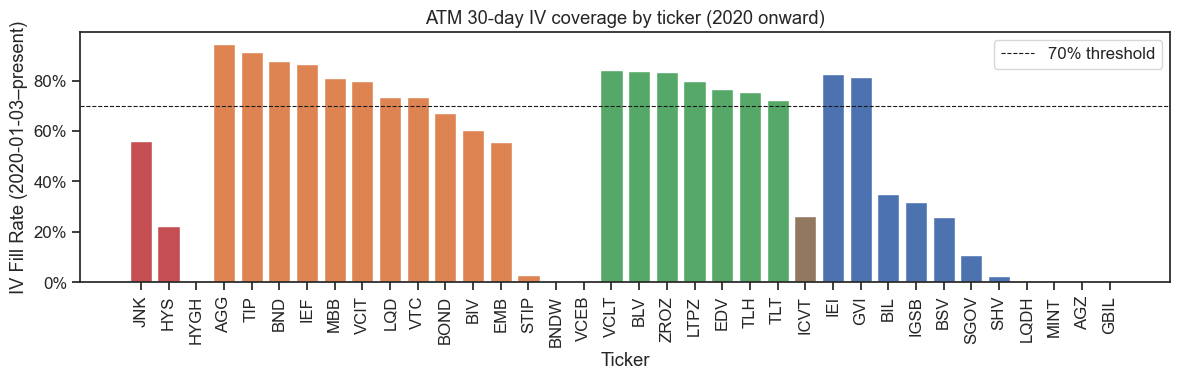


17 tickers ≥ 70% fill: ['AGG', 'BLV', 'BND', 'EDV', 'GVI', 'IEF', 'IEI', 'LQD', 'LTPZ', 'MBB', 'TIP', 'TLH', 'TLT', 'VCIT', 'VCLT', 'VTC', 'ZROZ']
ticker  fill_rate duration_bucket
   JNK     0.5606          credit
   HYS     0.2242          credit
  HYGH     0.0000          credit
   AGG     0.9455    intermediate
   TIP     0.9121    intermediate
   BND     0.8788    intermediate
   IEF     0.8667    intermediate
   MBB     0.8091    intermediate
  VCIT     0.7970    intermediate
   LQD     0.7364    intermediate
   VTC     0.7364    intermediate
  BOND     0.6697    intermediate
   BIV     0.6030    intermediate
   EMB     0.5545    intermediate
  STIP     0.0303    intermediate
  BNDW     0.0000    intermediate
  VCEB     0.0000    intermediate
  VCLT     0.8424            long
   BLV     0.8364            long
  ZROZ     0.8333            long
  LTPZ     0.7970            long
   EDV     0.7667            long
   TLH     0.7545            long
   TLT     0.7242            long
  

In [4]:
# Attach duration bucket to IV panel
iv_panel["category"]       = iv_panel["ticker"].map(UNIVERSE)
iv_panel["duration_bucket"] = iv_panel["ticker"].map(ticker_bucket)

# Coverage: fraction of Fridays WITH valid IV, restricted to the IV-fetch window (2020+)
# Pre-2020 core panel rows have no IV by construction — including them deflates fill rates.
IV_START = "2020-01-03"
iv_window = iv_panel[iv_panel["date"] >= IV_START]

coverage = (
    iv_window.groupby("ticker")["iv_30d"]
    .apply(lambda s: s.notna().mean())
    .rename("fill_rate")
    .reset_index()
)
coverage["duration_bucket"] = coverage["ticker"].map(ticker_bucket)
coverage = coverage.sort_values(["duration_bucket", "fill_rate"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = coverage["duration_bucket"].map(colors)
ax.bar(coverage["ticker"], coverage["fill_rate"], color=bar_colors)
ax.axhline(0.7, color="k", ls="--", lw=0.8, label="70% threshold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xlabel("Ticker")
ax.set_ylabel(f"IV Fill Rate ({IV_START}–present)")
ax.set_title("ATM 30-day IV coverage by ticker (2020 onward)")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "01_iv_coverage.png", dpi=150)
plt.show()

above_70 = coverage[coverage["fill_rate"] >= 0.7]["ticker"].tolist()
print(f"\n{len(above_70)} tickers ≥ 70% fill: {sorted(above_70)}")
print(coverage.to_string(index=False))

---
## 3. Rate-Space Exposures and Hedge Capacity

`hedge_capacity_ratio` = chain-level DV01 (option OI × rate_dv01 per contract) divided by fund DV01 (D_i × AUM × 0.0001). By the D_i cancellation identity, this reduces to `(100 · S · Σ|delta| · w) / AUM` — robust to noisy empirical duration estimates. It is an optimistic stock-of-open-interest measure, not executable order-book depth: it ignores price impact and treats qualifying OI as potentially available.

Loaded from `options_panel.csv` (built by Step 4 above or `scripts/04_build_options_panel.py`).


In [5]:
if options_panel.empty:
    print("Skip: options_panel.csv not built yet.")
else:
    op = options_panel.copy()
    op["duration_bucket"] = op["ticker"].map(ticker_bucket)

    # ── Cross-sectional summary: median hedge_capacity_ratio by ticker ──────
    hcap_by_ticker = (
        op.dropna(subset=["hedge_capacity_ratio"])
        .groupby("ticker")
        .agg(
            hcap_median=("hedge_capacity_ratio", "median"),
            hcap_mean=("hedge_capacity_ratio", "mean"),
            weight_basis_mode=("weight_basis", lambda s: s.mode().iloc[0] if len(s) else "unknown"),
            snap_dates=("date", "nunique"),
        )
        .reset_index()
    )
    hcap_by_ticker["duration_bucket"] = hcap_by_ticker["ticker"].map(ticker_bucket)
    bucket_order_map = {b: i for i, b in enumerate(BUCKET_ORDER)}
    hcap_by_ticker = hcap_by_ticker.sort_values(
        ["duration_bucket", "hcap_median"],
        key=lambda s: s.map(bucket_order_map) if s.name == "duration_bucket" else s,
        ascending=[True, False],
    )
    hcap_by_ticker.to_csv(cfg.TABLES_DIR / "hedge_capacity_by_ticker.csv", index=False)

    print("Median hedge_capacity_ratio by ticker:")
    print(hcap_by_ticker[[
        "ticker", "duration_bucket", "hcap_median", "hcap_mean", "weight_basis_mode", "snap_dates"
    ]].round(6).to_string(index=False))


Median hedge_capacity_ratio by ticker:
ticker duration_bucket  hcap_median  hcap_mean weight_basis_mode  snap_dates
   IEI           short       0.0009     0.0025     open_interest         330
  IGSB           short       0.0000     0.0000     open_interest         317
   BIL           short       0.0000     0.0000     open_interest         134
   AGZ           short       0.0000     0.0000     open_interest         134
   BSV           short       0.0000     0.0000     open_interest         225
   GVI           short       0.0000     0.0000     open_interest         265
  MINT           short       0.0000     0.0000     open_interest         186
  SGOV           short       0.0000     0.0000     open_interest          56
   SHV           short       0.0000     0.0000     open_interest         200
   LQD    intermediate       0.0291     0.0291     open_interest         317
   IEF    intermediate       0.0132     0.0137     open_interest         330
   EMB    intermediate       0.0122  

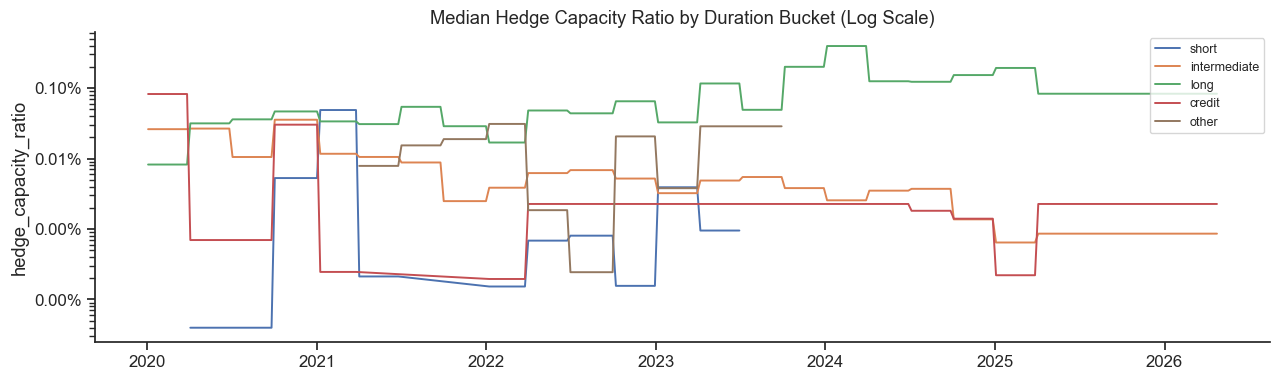

In [6]:
if not options_panel.empty and "hedge_capacity_ratio" in options_panel.columns:
    op = options_panel.dropna(subset=["hedge_capacity_ratio"]).copy()
    op["duration_bucket"] = op["ticker"].map(ticker_bucket)

    # Time-series: median hedge_capacity_ratio by duration bucket
    ts = (
        op.groupby(["date", "duration_bucket"])["hedge_capacity_ratio"]
        .median()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(13, 4))
    for bucket in BUCKET_ORDER:
        sub = ts[ts["duration_bucket"] == bucket]
        sub = sub[sub["hedge_capacity_ratio"] > 0]
        if not sub.empty:
            ax.plot(sub["date"], sub["hedge_capacity_ratio"], label=bucket,
                    color=colors.get(bucket), linewidth=1.4)
    ax.set_title("Median Hedge Capacity Ratio by Duration Bucket (Log Scale)")
    ax.set_ylabel("hedge_capacity_ratio")
    ax.set_yscale("log")
    ax.legend(loc="upper right", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    sns.despine()
    plt.tight_layout()
    plt.savefig(cfg.FIGURES_DIR / "hcap_ratio_ts.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skip: options_panel.csv not built yet.")


---
## 4. Empirical Rate-Duration Proxy

Rate-duration estimated by regressing weekly ETF returns on `d_DGS10` (weekly change in 10-year Treasury yield, in percentage points). `realized_rate_duration = −100 × beta_rate` (positive for long-duration ETFs; 52-week trailing window, min 40 observations).


In [7]:
# Rolling empirical duration from weekly ETF returns on 10-year yield changes.
# d_DGS10 is in percentage points, so duration = -100 * return beta.
core_duration_input = core_panel[core_panel["ticker"].isin(list(UNIVERSE.keys()))].copy()

duration_est = estimate_rolling_rate_duration(
    core_duration_input,
    window=52,
    min_obs=40,
    return_col="Return",
    yield_col="d_DGS10",
)

duration_latest = (
    duration_est.sort_values("date")
    .groupby("ticker", as_index=False)
    .tail(1)
)
duration_latest = duration_latest[duration_latest["ticker"].isin(list(UNIVERSE.keys()))].copy()
duration_latest["duration_bucket"] = duration_latest["ticker"].map(ticker_bucket)
bucket_order_map = {bucket: i for i, bucket in enumerate(BUCKET_ORDER)}
duration_latest["bucket_order"] = duration_latest["duration_bucket"].map(bucket_order_map)
duration_latest = (
    duration_latest
    .sort_values(["bucket_order", "realized_rate_duration"], ascending=[True, False])
    .drop(columns="bucket_order")
)

duration_latest.to_csv(cfg.TABLES_DIR / "empirical_duration_by_ticker.csv", index=False)

latest_print = duration_latest[[
    "ticker", "duration_bucket", "date", "realized_rate_duration",
    "realized_rate_duration_raw", "duration_r2", "duration_nobs",
]].copy()
numeric_cols = latest_print.select_dtypes(include="number").columns
latest_print[numeric_cols] = latest_print[numeric_cols].round(4)

print(f"Rolling duration estimates: {len(duration_est):,} ticker-weeks")
print("Latest empirical rate duration by ticker:")
print(latest_print.to_string(index=False))


Rolling duration estimates: 16,654 ticker-weeks
Latest empirical rate duration by ticker:
ticker duration_bucket       date  realized_rate_duration  realized_rate_duration_raw  duration_r2  duration_nobs
   IEI           short 2026-04-24                  4.4766                      4.4766       0.8682             52
   GVI           short 2026-04-24                  3.5960                      3.5960       0.8717             52
   AGZ           short 2026-04-24                  2.7448                      2.7448       0.6789             52
   BSV           short 2026-04-24                  2.5124                      2.5124       0.7766             52
  IGSB           short 2026-04-24                  2.5055                      2.5055       0.6762             52
  GBIL           short 2026-04-24                  0.0794                      0.0794       0.1612             52
   SHV           short 2026-04-24                  0.0780                      0.0780       0.1455             5

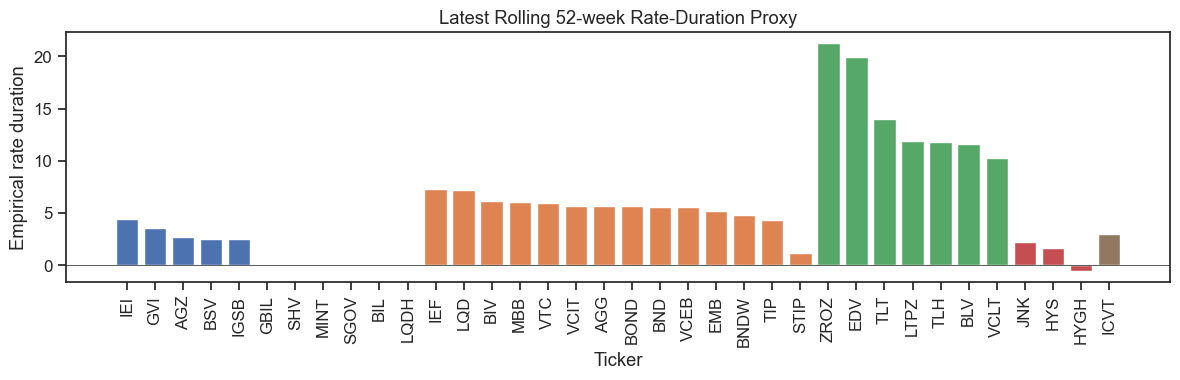

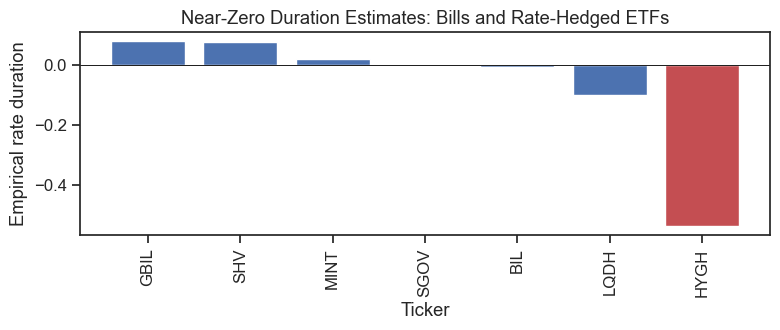

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = duration_latest["duration_bucket"].map(colors)
ax.bar(duration_latest["ticker"], duration_latest["realized_rate_duration"], color=bar_colors)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Ticker")
ax.set_ylabel("Empirical rate duration")
ax.set_title("Latest Rolling 52-week Rate-Duration Proxy")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "08_empirical_rate_duration_by_ticker.png", dpi=150)
plt.show()

# The all-ticker chart is dominated by long-duration funds. This zoom makes the
# near-zero bill and rate-hedged estimates visible instead of collapsed on zero.
low_duration = duration_latest[duration_latest["realized_rate_duration"].abs() <= 1.0].copy()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(
    low_duration["ticker"],
    low_duration["realized_rate_duration"],
    color=low_duration["duration_bucket"].map(colors),
)
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("Ticker")
ax.set_ylabel("Empirical rate duration")
ax.set_title("Near-Zero Duration Estimates: Bills and Rate-Hedged ETFs")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "09_empirical_rate_duration_zoom.png", dpi=150)
plt.show()


---
## 5. Duration-Scaled Greek Exposure (Robustness)

Legacy Greek-scaling approach (no OI required). Main purpose: cross-check that duration-normalized vega capacity aligns directionally with `hedge_capacity_ratio` from Section 3.


In [9]:
chains_duration = add_duration_exposure_features(chains, duration_est)
chains_duration = chains_duration[chains_duration["ticker"].isin(list(UNIVERSE.keys()))].copy()
chains_duration["duration_bucket"] = chains_duration["ticker"].map(ticker_bucket)

duration_exposure_summary, duration_exposure_by_ticker, duration_exposure_by_date_bucket, duration_exposure_by_ticker_date = summarize_duration_exposure(
    chains_duration,
    bucket_order=BUCKET_ORDER,
)

duration_exposure_sample = chains_duration.dropna(
    subset=[
        "realized_rate_duration", "dollar_duration", "duration_per_vega",
        "gamma_per_duration", "theta_per_duration",
    ]
).copy()

bucket_order_map = {bucket: i for i, bucket in enumerate(BUCKET_ORDER)}
duration_exposure_by_ticker["bucket_order"] = duration_exposure_by_ticker["duration_bucket"].map(bucket_order_map)
duration_exposure_by_ticker = (
    duration_exposure_by_ticker
    .sort_values(["bucket_order", "realized_rate_duration_mean"], ascending=[True, False])
    .drop(columns="bucket_order")
)

DISPLAY_MIN_QUALITY_CONTRACTS = 50
DISPLAY_MIN_QUALITY_SHARE = 0.25
quality_display_mask = (
    (duration_exposure_by_ticker["quality_contracts"] >= DISPLAY_MIN_QUALITY_CONTRACTS)
    & (duration_exposure_by_ticker["quality_share"] >= DISPLAY_MIN_QUALITY_SHARE)
)
duration_exposure_by_ticker["quality_display"] = quality_display_mask
quality_display_tickers = duration_exposure_by_ticker.loc[quality_display_mask, "ticker"]

_display_quality_cols = [
    "vega_per_100_duration_quality_median",
    "gamma_per_100_duration_quality_median",
    "theta_bp_per_duration_quality_median",
]
for col in _display_quality_cols:
    duration_exposure_by_ticker[f"{col}_display"] = duration_exposure_by_ticker[col].where(
        duration_exposure_by_ticker["quality_display"]
    )

duration_exposure_by_ticker_date_display = duration_exposure_by_ticker_date[
    duration_exposure_by_ticker_date["ticker"].isin(quality_display_tickers)
].copy()
duration_exposure_by_date_bucket_display = (
    duration_exposure_by_ticker_date_display
    .groupby(["snap_date", "duration_bucket"])
    .agg(
        dollar_duration_median=("dollar_duration_median", "median"),
        vega_per_100_dur_median=("vega_per_100_duration_quality_median", "median"),
    )
    .reset_index()
)

duration_exposure_summary.to_csv(cfg.TABLES_DIR / "duration_exposure_summary.csv", index=False)
duration_exposure_by_ticker.to_csv(cfg.TABLES_DIR / "duration_exposure_by_ticker.csv", index=False)
duration_exposure_by_ticker_date.to_csv(cfg.TABLES_DIR / "duration_exposure_by_ticker_date.csv", index=False)

print("Duration-scaled Greek exposures by duration bucket:")
print(duration_exposure_summary.set_index("duration_bucket").round(4))
print(f"\nRows with duration-scaled ratios: {len(duration_exposure_sample):,} / {len(chains_duration):,}")
print(f"Rows passing duration-quality guards: {int(duration_exposure_sample['duration_quality'].sum()):,}")


Duration-scaled Greek exposures by duration bucket:
                 realized_rate_duration_mean  realized_rate_duration_median  \
duration_bucket                                                               
short                                 2.0819                         2.3404   
intermediate                          6.3697                         7.1295   
long                                 16.7976                        15.5328   
credit                                0.9908                         1.1716   
other                                 0.5117                         1.3006   

                 duration_r2_mean  dollar_duration_median  \
duration_bucket                                             
short                      0.4877                 -5.4061   
intermediate               0.6450                -76.1701   
long                       0.8175                -79.5859   
credit                     0.1323                -23.1645   
other                      0

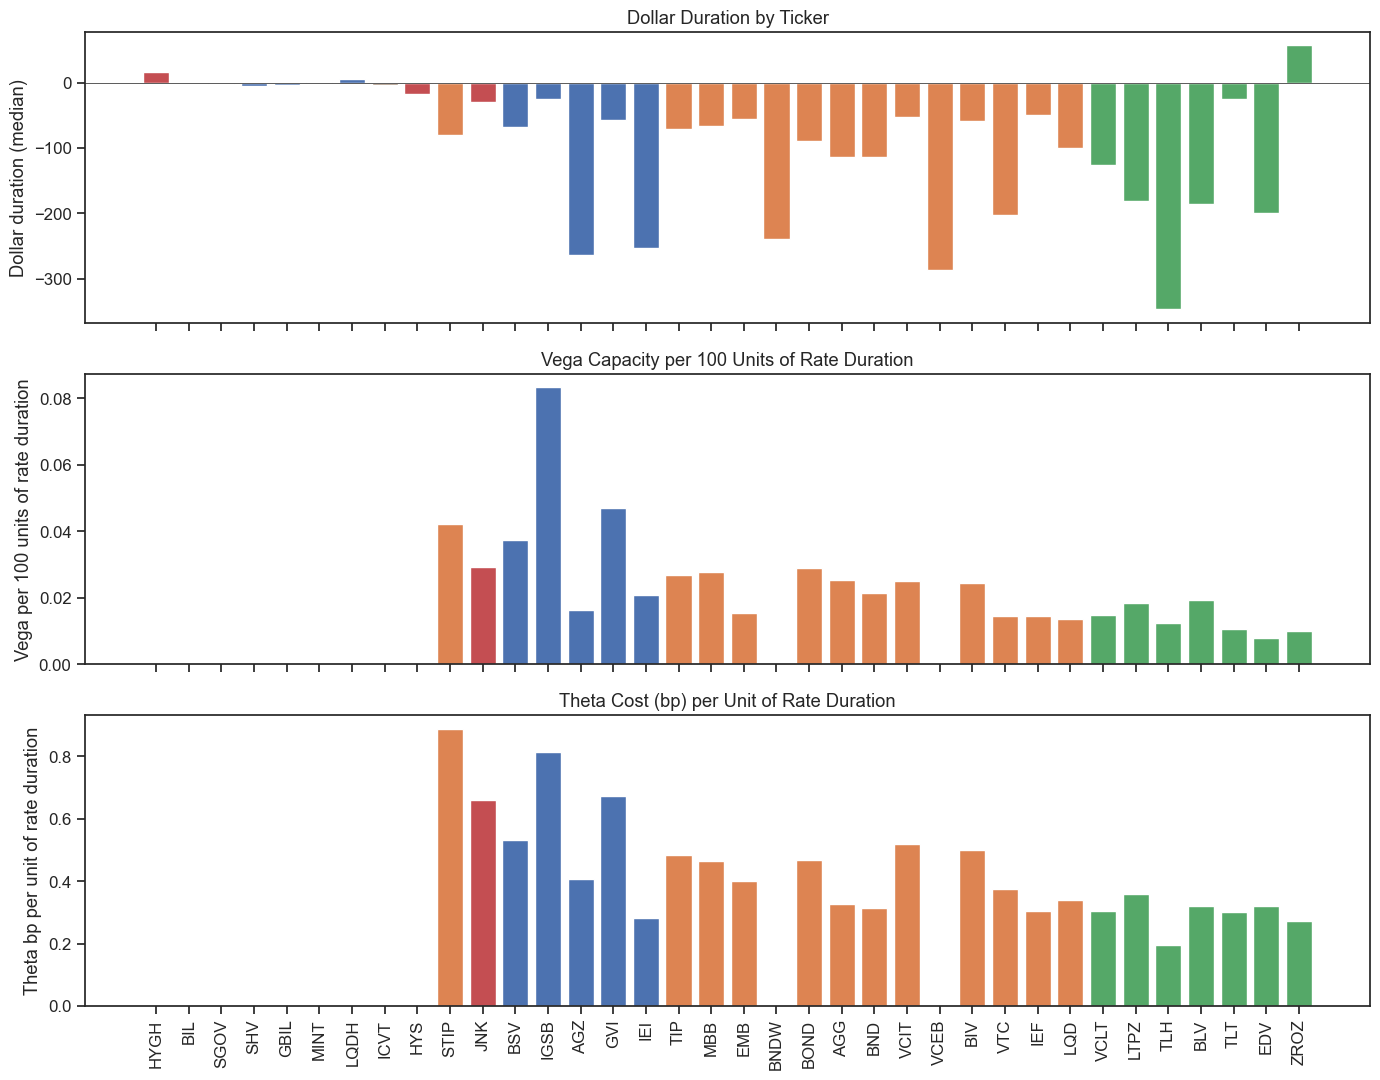

In [10]:
# Section 5 — Bar charts: duration-scaled Greek exposure by ticker
# Ordered by ascending realized rate duration (short → long reads left-to-right)
ordered = duration_exposure_by_ticker.sort_values("realized_rate_duration_mean", ascending=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

def _bar(ax, col, ylabel, title):
    vals = ordered[col]
    bar_colors = ordered["duration_bucket"].map(colors).where(vals.notna(), "#cccccc")
    ax.bar(ordered["ticker"], vals, color=bar_colors)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_bar(axes[0], "dollar_duration_median",
     "Dollar duration (median)", "Dollar Duration by Ticker")
_bar(axes[1], "vega_per_100_duration_quality_median_display",
     "Vega per 100 units of rate duration",
     "Vega Capacity per 100 Units of Rate Duration")
_bar(axes[2], "theta_bp_per_duration_quality_median_display",
     "Theta bp per unit of rate duration",
     "Theta Cost (bp) per Unit of Rate Duration")

plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "10_duration_scaled_greeks_by_ticker.png", dpi=150)
plt.show()


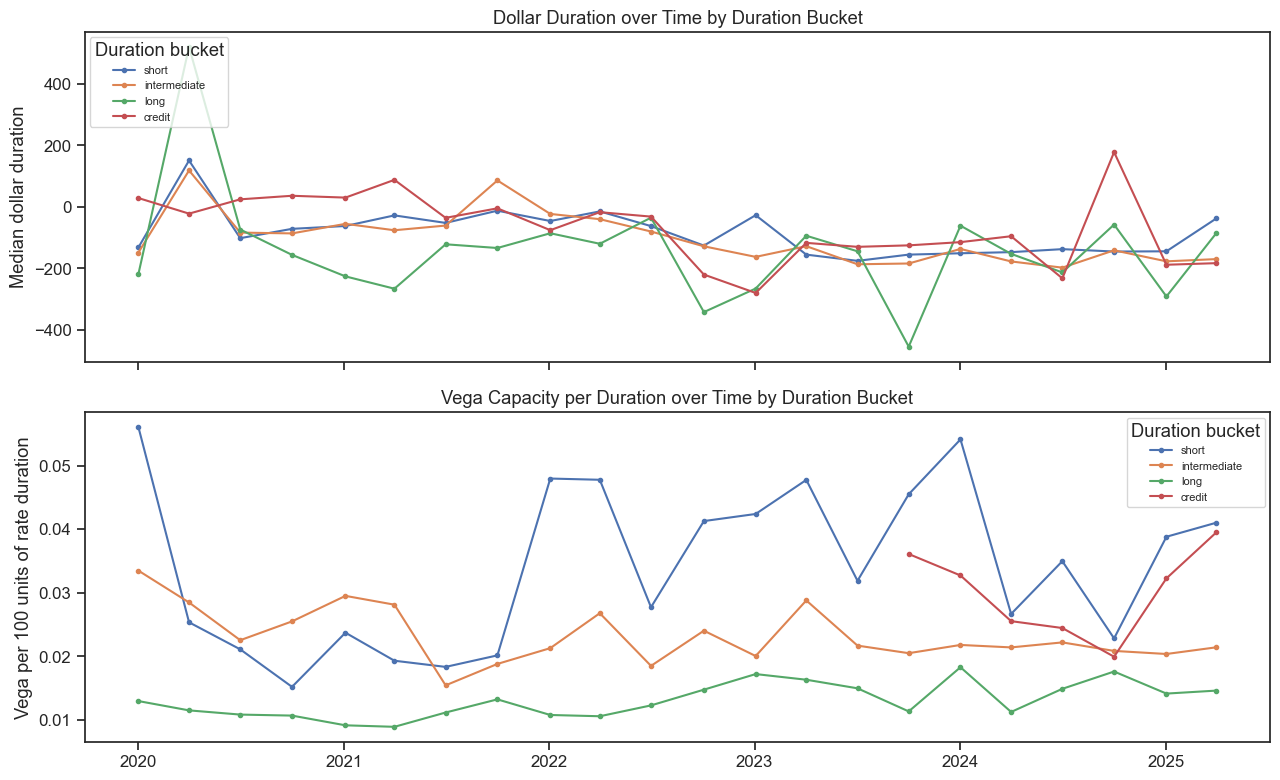

In [11]:
# Section 5 — Time-series: duration-scaled Greek exposure across quarterly snap dates
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for bucket in BUCKET_ORDER:
    sub = duration_exposure_by_date_bucket_display[
        duration_exposure_by_date_bucket_display["duration_bucket"] == bucket
    ]
    if sub.empty:
        continue
    c = colors.get(bucket, "#888")
    axes[0].plot(sub["snap_date"], sub["dollar_duration_median"],
                 label=bucket, color=c, marker="o", ms=3)
    axes[1].plot(sub["snap_date"], sub["vega_per_100_dur_median"],
                 label=bucket, color=c, marker="o", ms=3)

axes[0].set_ylabel("Median dollar duration")
axes[0].set_title("Dollar Duration over Time by Duration Bucket")
axes[0].legend(title="Duration bucket", loc="upper left", fontsize=8)

axes[1].set_ylabel("Vega per 100 units of rate duration")
axes[1].set_title("Vega Capacity per Duration over Time by Duration Bucket")
axes[1].legend(title="Duration bucket", loc="upper right", fontsize=8)

plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "12_duration_greeks_time_series.png", dpi=150)
plt.show()


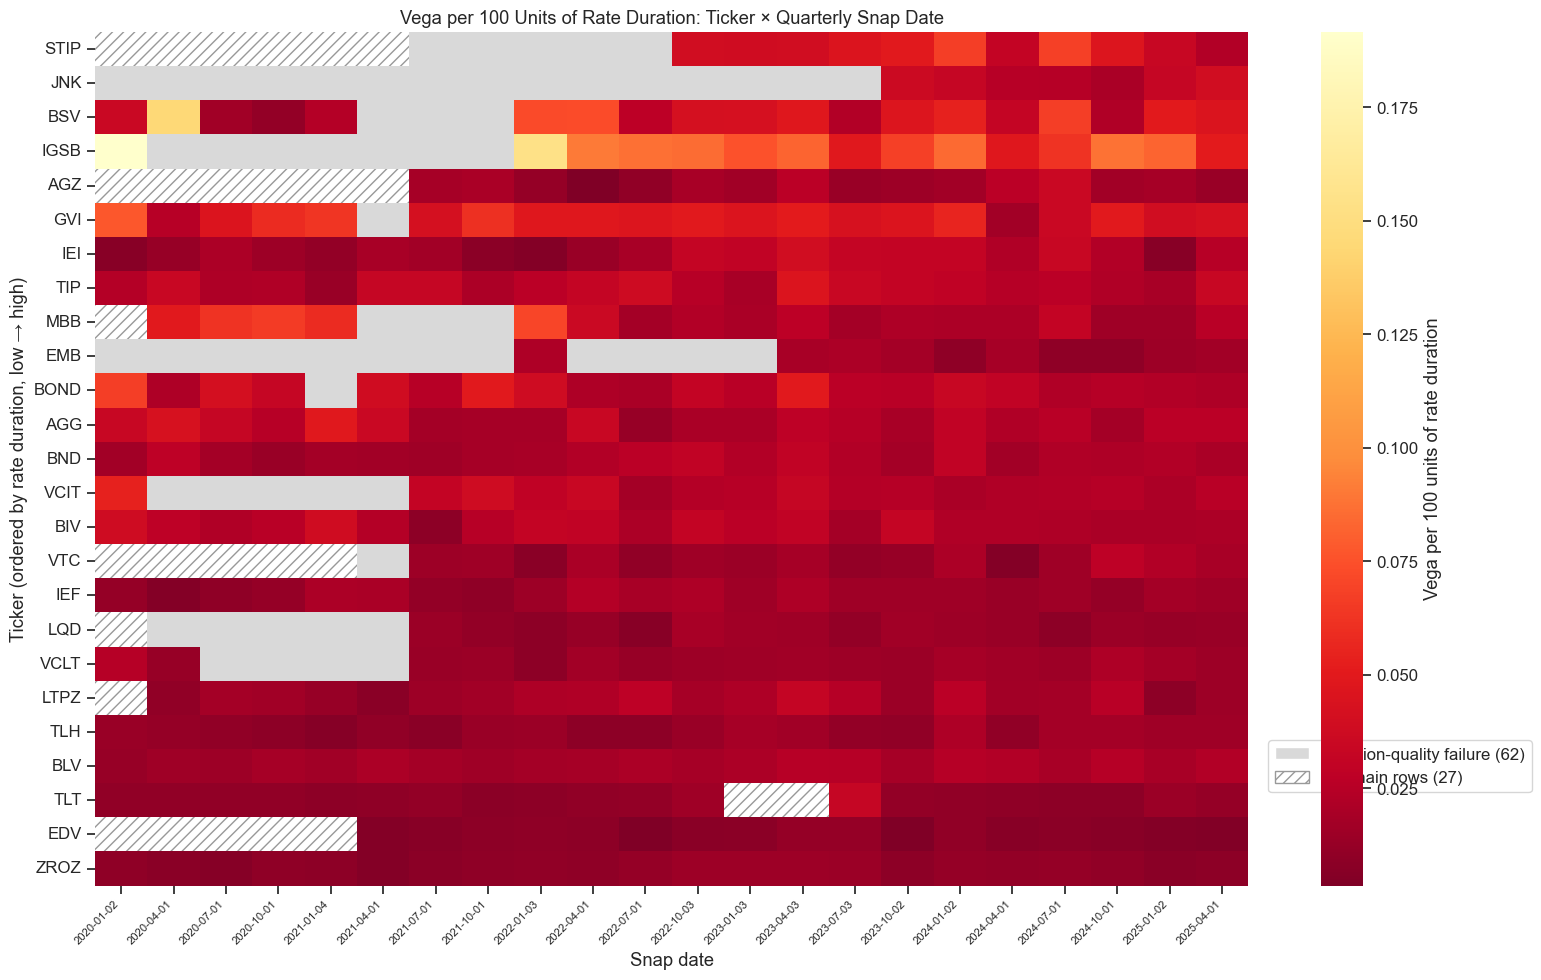

Missing heatmap cells: 89 = 62 duration-quality failures + 27 no-chain cells


In [12]:
# Section 5 — Heatmap: vega_per_100_duration_quality by ticker × snap_date
from matplotlib.patches import Patch, Rectangle

heatmap_df = duration_exposure_by_ticker_date_display.pivot(
    index="ticker",
    columns="snap_date",
    values="vega_per_100_duration_quality_median",
)

# Order tickers by ascending realized rate duration and retain the full date grid.
ticker_dur_order = (
    duration_exposure_by_ticker
    .sort_values("realized_rate_duration_mean", ascending=True)["ticker"]
    .tolist()
)
heatmap_tickers = [t for t in ticker_dur_order if t in quality_display_tickers.values]
heatmap_dates = sorted(pd.to_datetime(chains_duration["snap_date"].dropna().unique()))
heatmap_df = heatmap_df.reindex(index=heatmap_tickers, columns=heatmap_dates)

# Classify missing cells: gray = duration estimate failed its quality gate;
# hatched white = no option-chain rows exist for that ticker-snapshot.
observed_pairs = set(zip(
    chains_duration["ticker"], pd.to_datetime(chains_duration["snap_date"]),
))
missing_cells = int(heatmap_df.isna().sum().sum())
no_chain_cells = 0

cmap = plt.get_cmap("YlOrRd_r").copy()
cmap.set_bad("#d9d9d9")
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_df, ax=ax, cmap=cmap,
    cbar_kws={"label": "Vega per 100 units of rate duration"},
)
for row_i, ticker in enumerate(heatmap_df.index):
    for col_i, snap_date in enumerate(heatmap_df.columns):
        if pd.isna(heatmap_df.iloc[row_i, col_i]) and (ticker, snap_date) not in observed_pairs:
            no_chain_cells += 1
            ax.add_patch(Rectangle(
                (col_i, row_i), 1, 1, facecolor="white", edgecolor="#999999",
                hatch="///", linewidth=0.0,
            ))

duration_fail_cells = missing_cells - no_chain_cells
ax.legend(
    handles=[
        Patch(facecolor="#d9d9d9", label=f"Duration-quality failure ({duration_fail_cells})"),
        Patch(facecolor="white", edgecolor="#999999", hatch="///",
              label=f"No chain rows ({no_chain_cells})"),
    ],
    loc="upper left", bbox_to_anchor=(1.01, 0.18), frameon=True,
)
ax.set_xlabel("Snap date")
ax.set_ylabel("Ticker (ordered by rate duration, low → high)")
ax.set_title("Vega per 100 Units of Rate Duration: Ticker × Quarterly Snap Date")
ax.set_xticklabels(
    [str(c)[:10] for c in heatmap_df.columns], rotation=45, ha="right", fontsize=8
)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "13_vega_per_duration_heatmap.png", dpi=150)
plt.show()
print(f"Missing heatmap cells: {missing_cells} = "
      f"{duration_fail_cells} duration-quality failures + {no_chain_cells} no-chain cells")


---
## 6. Hedgeability Scores


In [13]:
hedge = compute_hedgeability_score(
    ticker_summary,
    core_panel.rename(columns={"ticker": "Symbol"}),
)
hedge = add_duration_normalized_hedgeability(
    hedge,
    duration_exposure_by_ticker,
    min_quality_contracts=DISPLAY_MIN_QUALITY_CONTRACTS,
    min_quality_share=DISPLAY_MIN_QUALITY_SHARE,
)

hedge.to_csv(cfg.TABLES_DIR / "hedgeability_scores.csv", index=False)

print(f"Hedgeability scores: {len(hedge)} liquid tickers")
print(f"  H_dur coverage: {hedge['H_dur'].notna().sum()} / {len(hedge)}")
display(
    hedge[[
        "ticker", "H", "hedgeability_tercile", "fragility_tercile",
        "fragility_hedgeability_group", "H_dur",
    ]].sort_values("H", ascending=False)
)


Hedgeability scores: 8 liquid tickers
  H_dur coverage: 8 / 8


,ticker,H,hedgeability_tercile,fragility_tercile,fragility_hedgeability_group,H_dur
5,TLT,1.9356,3,3,F3_H3,0.1865
7,ZROZ,0.9725,3,3,F3_H3,0.2954
4,TIP,0.9369,3,1,F1_H3,1.5277
3,LQD,0.5834,2,1,F1_H2,-0.4721
2,IEF,0.5102,2,1,F1_H2,0.9886
6,VCLT,-0.6934,1,2,F2_H1,0.6010
1,EMB,-2.1191,1,2,F2_H1,-1.8915
0,EDV,-2.1262,1,3,F3_H1,-1.2355


---
## 7. Convexity Capacity and Rate Carry

`convexity_capacity_ratio` measures the option chain's convexity (rate_conv) relative to the fund's dollar convexity. Unlike `hedge_capacity_ratio`, D_i does not cancel here — it scales as D_i², making it more sensitive to duration estimation noise and more informative about convexity-premium opportunities in long-duration funds.

`median_rate_carry` = median daily theta cost per unit of rate DV01 across quality contracts. High carry = expensive hedge; low carry = cheap insurance per unit of rate protection.

Both sourced from `options_panel.csv`.


In [14]:
if options_panel.empty:
    print("Skip: options_panel.csv not built yet.")
else:
    # ── Convexity capacity ratio by ticker ───────────────────────────────────
    op = options_panel.copy()
    op["duration_bucket"] = op["ticker"].map(ticker_bucket)

    conv_cols = ["ticker", "date", "duration_bucket",
                 "convexity_capacity_ratio", "hedge_capacity_ratio", "median_rate_carry"]
    op_conv = op[[c for c in conv_cols if c in op.columns]].dropna(subset=["convexity_capacity_ratio"])

    conv_by_ticker = (
        op_conv.groupby("ticker")
        .agg(
            conv_median=("convexity_capacity_ratio", "median"),
            hcap_median=("hedge_capacity_ratio", "median"),
            carry_median=("median_rate_carry", "median"),
        )
        .reset_index()
    )
    conv_by_ticker["duration_bucket"] = conv_by_ticker["ticker"].map(ticker_bucket)
    conv_by_ticker = conv_by_ticker.sort_values("conv_median", ascending=False)
    conv_by_ticker.to_csv(cfg.TABLES_DIR / "convexity_carry_by_ticker.csv", index=False)

    print("Convexity capacity ratio and rate carry by ticker (medians):")
    print(conv_by_ticker.round(6).to_string(index=False))


Convexity capacity ratio and rate carry by ticker (medians):
ticker  conv_median  hcap_median  carry_median duration_bucket
   TLT      85.2539       0.0570        0.0025            long
   LQD      38.5417       0.0285        0.0025    intermediate
   IEF      31.8445       0.0132        0.0029    intermediate
   IEI       3.2170       0.0009        0.0028           short
   TIP       1.9061       0.0021        0.0031    intermediate
   EDV       1.0406       0.0020        0.0021            long
  ZROZ       0.6154       0.0017        0.0019            long
  VCLT       0.5313       0.0004        0.0023            long
  LTPZ       0.3132       0.0008        0.0024            long
   TLH       0.1384       0.0001        0.0015            long
   AGG       0.0774       0.0001        0.0024    intermediate
   BLV       0.0543       0.0001        0.0021            long
   EMB       0.0211       0.0005        0.0031    intermediate
   BND       0.0150       0.0000        0.0022    interme

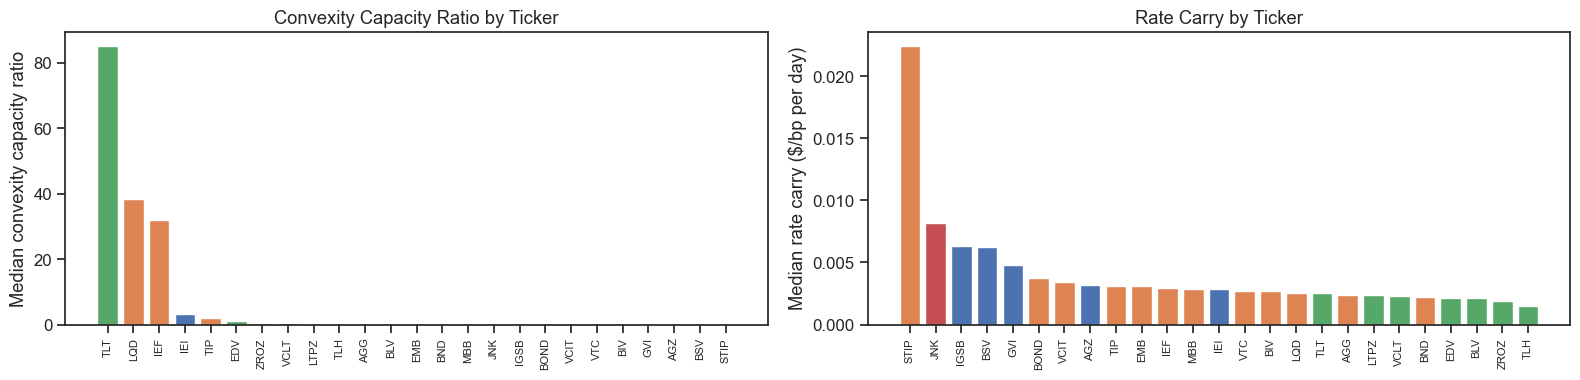

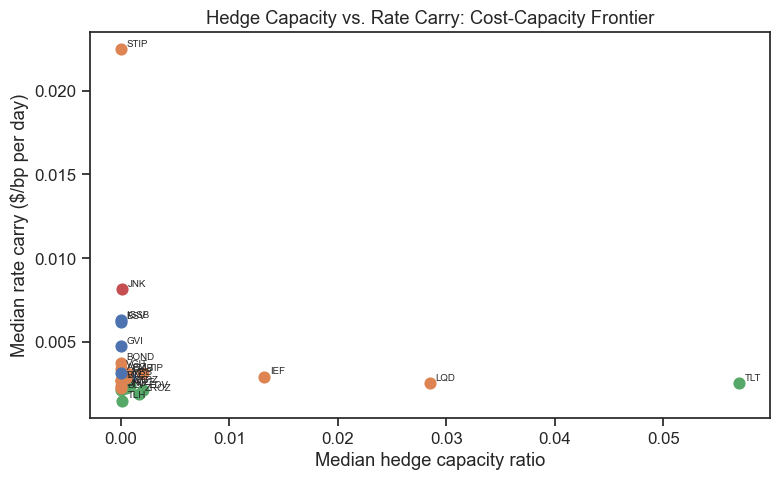

In [15]:
if not options_panel.empty and not conv_by_ticker.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    def _hbar(ax, df, col, ylabel, title):
        df = df.dropna(subset=[col]).sort_values(col, ascending=False)
        ax.bar(df["ticker"], df[col], color=df["duration_bucket"].map(colors))
        ax.axhline(0, color="k", lw=0.5)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)

    _hbar(axes[0], conv_by_ticker, "conv_median",
          "Median convexity capacity ratio", "Convexity Capacity Ratio by Ticker")
    _hbar(axes[1], conv_by_ticker, "carry_median",
          "Median rate carry ($/bp per day)", "Rate Carry by Ticker")

    plt.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / "22_convexity_carry_by_ticker.png", dpi=150)
    plt.show()

    # Scatter: hedge capacity vs rate carry (cost-vs-capacity frontier)
    scatter = conv_by_ticker.dropna(subset=["hcap_median", "carry_median"])
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, row in scatter.iterrows():
        ax.scatter(row["hcap_median"], row["carry_median"],
                   color=colors.get(row["duration_bucket"], "#888"), s=60, zorder=3)
        ax.annotate(row["ticker"], (row["hcap_median"], row["carry_median"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
    ax.set_xlabel("Median hedge capacity ratio")
    ax.set_ylabel("Median rate carry ($/bp per day)")
    ax.set_title("Hedge Capacity vs. Rate Carry: Cost-Capacity Frontier")
    plt.tight_layout()
    fig.savefig(cfg.FIGURES_DIR / "23_hcap_vs_carry_scatter.png", dpi=150)
    plt.show()


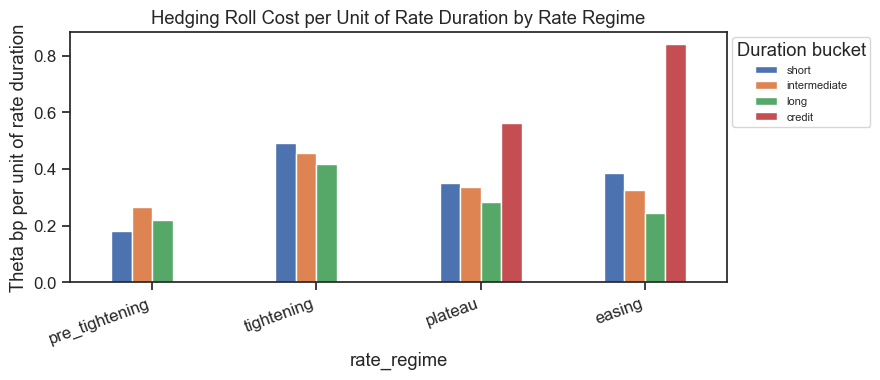

Roll-cost regime summary, quality-filtered ticker-snap medians:
   rate_regime duration_bucket  theta_p25  theta_median  theta_p75  theta_change_vs_pre  theta_ratio_vs_pre  ticker_snap_obs  tickers
pre_tightening           short     0.1667        0.1808     0.2028               0.0000              1.0000                8        2
pre_tightening    intermediate     0.2054        0.2652     0.4361               0.0000              1.0000               38        8
pre_tightening            long     0.1664        0.2213     0.2635               0.0000              1.0000               42        7
    tightening           short     0.4427        0.4901     0.6726               0.3093              2.7105                9        2
    tightening    intermediate     0.3619        0.4576     0.5432               0.1924              1.7255               43        9
    tightening            long     0.3308        0.4174     0.5224               0.1961              1.8863               40        

In [16]:
# Section 7 — Roll-cost regime summary from ticker × snap-date exposure rows
RATE_REGIME_ORDER = ["pre_tightening", "tightening", "plateau", "easing"]

roll_cost_by_regime, roll_cost_time_series, roll_cost_vega_tradeoff = summarize_roll_cost_by_regime(
    duration_exposure_by_ticker_date,
    bucket_order=BUCKET_ORDER,
    min_quality_contracts=DISPLAY_MIN_QUALITY_CONTRACTS,
    min_quality_share=DISPLAY_MIN_QUALITY_SHARE,
)

roll_cost_by_regime.to_csv(cfg.TABLES_DIR / "roll_cost_by_regime.csv", index=False)
roll_cost_time_series.to_csv(cfg.TABLES_DIR / "roll_cost_time_series.csv", index=False)
roll_cost_vega_tradeoff.to_csv(cfg.TABLES_DIR / "roll_cost_vega_tradeoff.csv", index=False)

theta_by_regime = (
    roll_cost_by_regime
    .pivot(index="rate_regime", columns="duration_bucket", values="theta_median")
    .reindex(RATE_REGIME_ORDER)
    [[b for b in BUCKET_ORDER if b in roll_cost_by_regime["duration_bucket"].astype(str).unique()]]
)

fig, ax = plt.subplots(figsize=(9, 4))
theta_by_regime.plot(
    kind="bar",
    ax=ax,
    color=[colors.get(str(b), "#888") for b in theta_by_regime.columns],
)
ax.set_ylabel("Theta bp per unit of rate duration")
ax.set_title("Hedging Roll Cost per Unit of Rate Duration by Rate Regime")
ax.legend(title="Duration bucket", bbox_to_anchor=(1, 1), fontsize=8)
ax.set_xticklabels(theta_by_regime.index, rotation=20, ha="right")
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "15_roll_cost_by_regime.png", dpi=150)
plt.show()

print("Roll-cost regime summary, quality-filtered ticker-snap medians:")
print(
    roll_cost_by_regime[[
        "rate_regime", "duration_bucket", "theta_p25", "theta_median", "theta_p75",
        "theta_change_vs_pre", "theta_ratio_vs_pre", "ticker_snap_obs", "tickers",
    ]].round(4).to_string(index=False)
)


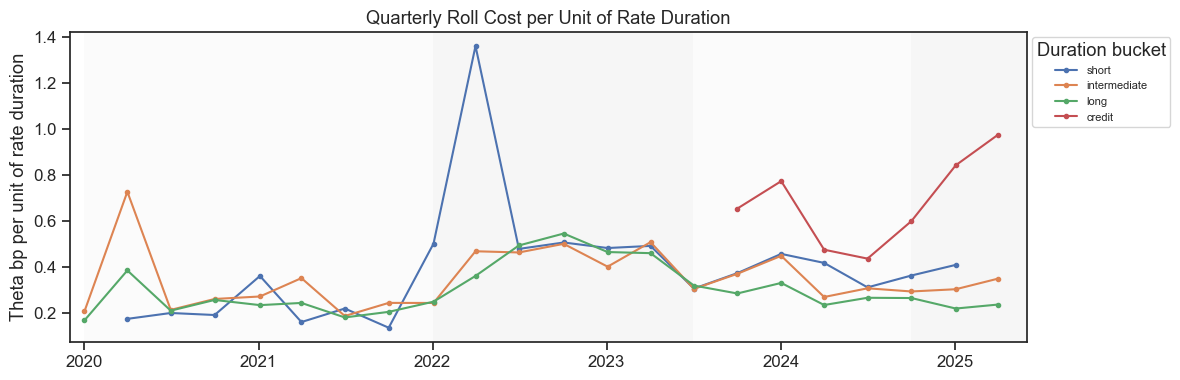

In [17]:
# Section 7 — Quarterly roll-cost time series by duration bucket
fig, ax = plt.subplots(figsize=(12, 4))
for bucket in [b for b in BUCKET_ORDER if b in roll_cost_time_series["duration_bucket"].astype(str).unique()]:
    s = roll_cost_time_series[roll_cost_time_series["duration_bucket"].astype(str) == bucket]
    ax.plot(
        s["snap_date"], s["theta_median"], marker="o", ms=3, lw=1.5,
        label=bucket, color=colors.get(bucket),
    )

plot_start = roll_cost_time_series["snap_date"].min() - pd.Timedelta(days=30)
plot_end = roll_cost_time_series["snap_date"].max() + pd.Timedelta(days=60)
regime_spans = [
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2022-01-01"), 0.15),
    (pd.Timestamp("2022-01-01"), pd.Timestamp("2023-07-01"), 0.35),
    (pd.Timestamp("2023-07-01"), pd.Timestamp("2024-10-01"), 0.15),
    (pd.Timestamp("2024-10-01"), plot_end, 0.35),
]
for start, end, alpha in regime_spans:
    ax.axvspan(max(start, plot_start), min(end, plot_end), color="0.9", alpha=alpha, lw=0)

ax.set_xlim(plot_start, plot_end)
ax.set_ylabel("Theta bp per unit of rate duration")
ax.set_title("Quarterly Roll Cost per Unit of Rate Duration")
ax.legend(title="Duration bucket", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
fig.savefig(cfg.FIGURES_DIR / "16_roll_cost_time_series.png", dpi=150)
plt.show()


---
## 8. IV-Realized Variance Gap (Appendix Diagnostic)

IVRVG = iv² − RV² (ex-ante, no lookahead). The null-test regressions in Section 9 show IVRVG is not a robust predictor of returns or forward volatility. This appendix diagnostic establishes that option-price levels are not the paper's main result; Section 10 instead decomposes the cross-sectional composition of option-market depth.


In [18]:
iv_vrp = compute_vrp(iv_panel[iv_panel["date"] >= IV_START].dropna(
    subset=["iv_30d", "vol_12w_annualized"]
))
iv_vrp = add_rate_duration_to_panel(iv_vrp, duration_est)

# Ex-ante: iv_30d^2 - trailing_RV^2  (safe predictor - no lookahead)
# Ex-post: iv_30d^2 - forward_RV^2   (descriptive only - uses future data)
print("Ex-ante IV-realized variance gap (vrp):")
print(iv_vrp["vrp"].describe().round(6))
if "vrp_ex_post_12w" in iv_vrp.columns:
    print("\nEx-post VRP (vrp_ex_post_12w):")
    print(iv_vrp["vrp_ex_post_12w"].dropna().describe().round(6))

iv_duration_summary = (
    iv_vrp.dropna(subset=["vrp", "realized_rate_duration"])
    .groupby("duration_bucket")
    .agg(
        realized_rate_duration_mean=("realized_rate_duration", "mean"),
        duration_r2_mean=("duration_r2", "mean"),
        duration_quality_rate=("duration_quality", "mean"),
        vrp_mean=("vrp", "mean"),
        vrp_per_duration_quality_mean=("vrp_per_duration_quality", "mean"),
        vrp_x_duration_quality_mean=("vrp_x_duration_quality", "mean"),
        obs=("ticker", "size"),
    )
    .reindex([b for b in BUCKET_ORDER if b in iv_vrp["duration_bucket"].dropna().unique()])
)
iv_duration_summary.to_csv(cfg.TABLES_DIR / "duration_scaled_vrp_summary.csv")

print("\nDuration-scaled IVRVG summary by bucket:")
print(iv_duration_summary.round(6))


Ex-ante IV-realized variance gap (vrp):
count   5886.0000
mean       0.0011
std        0.0249
min       -0.4423
25%        0.0001
50%        0.0018
75%        0.0048
max        0.3456
Name: vrp, dtype: float64

Ex-post VRP (vrp_ex_post_12w):
count   5668.0000
mean       0.0023
std        0.0214
min       -0.4689
25%       -0.0000
50%        0.0020
75%        0.0054
max        0.3312
Name: vrp_ex_post_12w, dtype: float64

Duration-scaled IVRVG summary by bucket:
                 realized_rate_duration_mean  duration_r2_mean  \
duration_bucket                                                  
short                                 2.7703            0.6298   
intermediate                          5.8449            0.7162   
long                                 15.8751            0.7688   
credit                                1.1840            0.1112   
other                                -0.8501            0.0270   

                 duration_quality_rate  vrp_mean  \
duration_bucket    

---
## 9. Predictive Regressions

**Descriptive baseline (Spec 0):** `hedge_capacity_ratio → fwd_maxdd_12w` (date FEs, CGM SE). A protective relation would be positive because drawdowns are negative; the observed coefficient is negative. Section 10 tests whether this pooled association is within-ticker protection or persistent between-fund composition.

**Secondary diagnostics (Specs 1–7):** IVRVG, duration, H/H_dur, and vega_per_dur. These are not interpreted causally and do not supersede the fixed-effect, Mundlak, and call/put evidence in Section 10.

Standard errors: CGM (2011) two-way cluster on ticker × date throughout.

**Fixed effects by spec:**
- Specs 1, 4, 5: **Ticker FEs** — IVRVG varies within ticker over time.
- Specs 0, 2, 2b, 3, 6, 7: **Date FEs** — slow-moving cross-sectional regressors need date FEs to avoid ticker-FE absorption.


In [19]:
# ── Spec 0: pooled descriptive association; decomposed in Section 10 ────────
if options_panel.empty:
    print("Skip Spec 0: options_panel.csv not built yet.")
else:
    reg0 = (
        options_panel
        .dropna(subset=["hedge_capacity_ratio", "fwd_maxdd_12w"])
        .copy()
    )
    reg0["date_grp"] = pd.to_datetime(reg0["date"]).dt.strftime("%Y-%m-%d")

    tbl0 = cgm_summary(
        f"fwd_maxdd_12w ~ hedge_capacity_ratio + C(date_grp)",
        reg0.assign(date=reg0["date_grp"]),
        ["hedge_capacity_ratio"],
    )
    print("Spec 0 (POOLED BASELINE): hedge_capacity_ratio → fwd_maxdd_12w (date FEs, CGM SE)")
    print(f"Sample: {len(reg0):,} obs, {reg0['ticker'].nunique()} tickers")
    print(tbl0.round(4))
    print()
    print("A protective relation requires positive β because fwd_maxdd_12w is negative.")
    print("The observed negative coefficient is decomposed into within/between and call/put components in Section 10.")


Spec 0 (POOLED BASELINE): hedge_capacity_ratio → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 8,611 obs, 32 tickers
                        coef  se_cgm   t_cgm  p_cgm
hedge_capacity_ratio -0.2682  0.0922 -2.9086 0.0036

A protective relation requires positive β because fwd_maxdd_12w is negative.
The observed negative coefficient is decomposed into within/between and call/put components in Section 10.


In [20]:
# Regression base frame — forward returns merged with hedgeability and latest-prior option-screen metrics
# vrp_per_duration_quality is already in iv_vrp (added by add_rate_duration_to_panel in Section 7)
reg = iv_vrp.dropna(subset=["vrp", "fwd_ret_4w"]).copy()
reg = reg.merge(
    hedge[["ticker", "H", "H_dur", "hedgeability_tercile", "fragility_tercile"]],
    on="ticker", how="left",
)

reg = add_latest_duration_exposure_to_panel(
    reg,
    duration_exposure_by_ticker_date,
    exposure_cols=[
        "vega_per_100_duration_quality_median",
        "gamma_per_100_duration_quality_median",
        "theta_bp_per_duration_quality_median",
        "quality_contracts",
        "quality_share",
    ],
)
reg["vega_per_dur"]  = reg["vega_per_100_duration_quality_median"]
reg["theta_per_dur"] = reg["theta_bp_per_duration_quality_median"]

reg["date_str"] = reg["date"].dt.strftime("%Y-%m-%d")
reg = reg.rename(columns={"date_str": "date_grp"})

n_total  = len(reg)
t_total  = reg["ticker"].nunique()
n_hdur   = reg["H_dur"].notna().sum()
t_hdur   = reg[reg["H_dur"].notna()]["ticker"].nunique()
n_vega   = reg["vega_per_dur"].notna().sum()
t_vega   = reg[reg["vega_per_dur"].notna()]["ticker"].nunique()
print(f"Regression sample:     {n_total:,} obs, {t_total} tickers")
print(f"H_dur coverage:        {n_hdur:,} obs, {t_hdur} tickers")
print(f"vega_per_dur coverage: {n_vega:,} obs, {t_vega} tickers")


Regression sample:     5,830 obs, 31 tickers
H_dur coverage:        2,042 obs, 8 tickers
vega_per_dur coverage: 4,957 obs, 25 tickers


In [21]:
# Spec 1: IV-realized variance gap -> forward return
FE = "C(ticker)"
f1 = f"fwd_ret_4w ~ vrp + {FE}"
tbl1 = cgm_summary(f1, reg.assign(date=reg["date_grp"]), ["vrp"])
print("Spec 1: IV-realized variance gap -> fwd_ret_4w (CGM SE)")
print(tbl1.round(4))

Spec 1: IV-realized variance gap -> fwd_ret_4w (CGM SE)
       coef  se_cgm   t_cgm  p_cgm
vrp -0.0416  0.0487 -0.8531 0.3936


In [22]:
# Spec 2: IV-realized variance gap x long-duration — DATE FEs (not ticker FEs: duration_long is time-invariant)
# date FEs control for common time shocks; cross-sectional variation in duration_long identifies it
DATE_FE = "C(date_grp)"
reg["duration_long"] = (reg["duration_bucket"] == "long").astype(float)
f2 = f"fwd_ret_4w ~ vrp * duration_long + {DATE_FE}"
tbl2 = cgm_summary(f2, reg.assign(date=reg["date_grp"]),
                   ["vrp", "duration_long", "vrp:duration_long"])
print("Spec 2: IV-realized variance gap x long-duration (date FEs, CGM SE)")
print(tbl2.round(4))

Spec 2: IV-realized variance gap x long-duration (date FEs, CGM SE)
                     coef  se_cgm   t_cgm  p_cgm
vrp               -0.0729  0.0654 -1.1146 0.2650
duration_long     -0.0040  0.0020 -1.9995 0.0456
vrp:duration_long  0.0301  0.0678  0.4438 0.6572


In [23]:
# Spec 2b: continuous realized_rate_duration → fwd_ret_4w (date FEs, CGM SE)
# Continuous analog to Spec 2's binary duration_long dummy
reg2b = reg.dropna(subset=["realized_rate_duration", "fwd_ret_4w"]).copy()
f2b = f"fwd_ret_4w ~ vrp + realized_rate_duration + {DATE_FE}"
tbl2b = cgm_summary(f2b, reg2b.assign(date=reg2b["date_grp"]),
                    ["vrp", "realized_rate_duration"])
print(f"Spec 2b: IVRVG + realized_rate_duration \u2192 fwd_ret_4w (date FEs, CGM SE)")
print(f"Sample: {len(reg2b):,} obs, {reg2b['ticker'].nunique()} tickers")
print(tbl2b.round(4))


Spec 2b: IVRVG + realized_rate_duration → fwd_ret_4w (date FEs, CGM SE)
Sample: 5,830 obs, 31 tickers
                          coef  se_cgm   t_cgm  p_cgm
vrp                    -0.0515  0.0326 -1.5830 0.1134
realized_rate_duration -0.0003  0.0002 -1.9160 0.0554


In [24]:
# Spec 3a: H score → forward return — DATE FEs (H is time-invariant per ticker)
# Identifies: after absorbing common date effects, do higher-H tickers earn higher returns?
f3 = f"fwd_ret_4w ~ H + {DATE_FE}"
tbl3 = cgm_summary(f3, reg.assign(date=reg["date_grp"]), ["H"])
print("Spec 3a: Hedgeability (H) → fwd_ret_4w (date FEs, CGM SE)")
print(tbl3.round(4))

# Spec 3b: duration-normalized H_dur — same identification logic
# Controls for the mechanical scale effect of long duration on raw Greek magnitudes
reg3b = reg.dropna(subset=["H_dur", "fwd_ret_4w"]).copy()
f3b = f"fwd_ret_4w ~ H_dur + {DATE_FE}"
tbl3b = cgm_summary(f3b, reg3b.assign(date=reg3b["date_grp"]), ["H_dur"])
n3b = len(reg3b)
t3b = reg3b["ticker"].nunique()
print(f"\nSpec 3b: Duration-normalized hedgeability (H_dur) → fwd_ret_4w (date FEs, CGM SE)")
print(f"Sample: {n3b:,} obs, {t3b} tickers")
print(tbl3b.round(4))


Spec 3a: Hedgeability (H) → fwd_ret_4w (date FEs, CGM SE)
     coef  se_cgm   t_cgm  p_cgm
H -0.0001  0.0012 -0.0553 0.9559



Spec 3b: Duration-normalized hedgeability (H_dur) → fwd_ret_4w (date FEs, CGM SE)
Sample: 2,042 obs, 8 tickers
        coef  se_cgm  t_cgm  p_cgm
H_dur 0.0005  0.0013 0.3985 0.6903


In [25]:
# Spec 4: ex-ante variance gap → forward annualized realized vol
# fwd_vol_12w_annualized = fwd_vol_12w × √52, computed by compute_vrp
reg_vol = iv_vrp.dropna(subset=["vrp", "fwd_vol_12w_annualized"]).copy()
reg_vol["date"] = reg_vol["date"].dt.strftime("%Y-%m-%d")
f4 = f"fwd_vol_12w_annualized ~ vrp + {FE}"
tbl4 = cgm_summary(f4, reg_vol, ["vrp"])
print("Spec 4: ex-ante IVRVG → fwd_vol_12w_annualized (ticker FEs, CGM SE)")
print(tbl4.round(4))

Spec 4: ex-ante IVRVG → fwd_vol_12w_annualized (ticker FEs, CGM SE)
      coef  se_cgm  t_cgm  p_cgm
vrp 0.1552  0.0817 1.8987 0.0576


In [26]:
# Spec 5: duration-normalized IV-realized variance gap -> forward return
reg_duration = reg.dropna(subset=["vrp_per_duration_quality", "fwd_ret_4w"]).copy()
f5 = f"fwd_ret_4w ~ vrp_per_duration_quality + {FE}"
tbl5 = cgm_summary(
    f5,
    reg_duration.assign(date=reg_duration["date_grp"]),
    ["vrp_per_duration_quality"],
)
print("Spec 5: duration-normalized IVRVG → fwd_ret_4w (quality-filtered duration, ticker FEs, CGM SE)")
print(f"Sample: {len(reg_duration):,} obs, {reg_duration['ticker'].nunique()} tickers")
print(tbl5.round(4))


Spec 5: duration-normalized IVRVG → fwd_ret_4w (quality-filtered duration, ticker FEs, CGM SE)
Sample: 5,050 obs, 25 tickers
                           coef  se_cgm  t_cgm  p_cgm
vrp_per_duration_quality 0.0331  1.3223 0.0251 0.9800


In [27]:
# Spec 6: latest-prior duration-normalized vega capacity → forward drawdown
# H0: ETFs with more vega per unit of rate exposure hedge more cheaply → smaller drawdowns
reg6 = reg.dropna(subset=["vega_per_dur", "fwd_maxdd_12w"]).copy()
f6   = f"fwd_maxdd_12w ~ vega_per_dur + {DATE_FE}"
tbl6 = cgm_summary(f6, reg6.assign(date=reg6["date_grp"]), ["vega_per_dur"])
print("Spec 6: latest-prior vega per unit duration → fwd_maxdd_12w (date FEs, CGM SE)")
print(f"Sample: {len(reg6):,} obs, {reg6['ticker'].nunique()} tickers")
print(tbl6.round(4))


Spec 6: latest-prior vega per unit duration → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 4,811 obs, 25 tickers
               coef  se_cgm  t_cgm  p_cgm
vega_per_dur 1.0362  0.2829 3.6633 0.0002


In [28]:
# Spec 7: H_dur + duration_long → fwd_maxdd_12w (date FEs, CGM SE)
# Tests whether higher duration-normalized hedgeability reduces forward max drawdown
reg7 = reg.dropna(subset=["H_dur", "fwd_maxdd_12w"]).copy()
f7 = f"fwd_maxdd_12w ~ H_dur + duration_long + {DATE_FE}"
tbl7 = cgm_summary(f7, reg7.assign(date=reg7["date_grp"]), ["H_dur", "duration_long"])
print(f"Spec 7: H_dur + duration_long \u2192 fwd_maxdd_12w (date FEs, CGM SE)")
print(f"Sample: {len(reg7):,} obs, {reg7['ticker'].nunique()} tickers")
print(tbl7.round(4))


Spec 7: H_dur + duration_long → fwd_maxdd_12w (date FEs, CGM SE)
Sample: 2,002 obs, 8 tickers
                 coef  se_cgm   t_cgm  p_cgm
H_dur          0.0074  0.0032  2.2929 0.0219
duration_long -0.0449  0.0126 -3.5653 0.0004


In [29]:
# Combined regression table (all 9 specifications)
all_specs = {
    "(1) IVRVG \u2192 ret":                tbl1,
    "(2) IVRVG \xd7 long \u2192 ret":    tbl2,
    "(2b) IVRVG + duration \u2192 ret":   tbl2b,
    "(3a) H \u2192 ret":                  tbl3,
    "(3b) H_dur \u2192 ret":              tbl3b,
    "(4) IVRVG \u2192 fwd_vol":           tbl4,
    "(5) IVRVG/duration \u2192 ret":      tbl5,
    "(6) vega/duration \u2192 drawdown":  tbl6,
    "(7) H_dur + long \u2192 drawdown":   tbl7,
}
rows = []
for name, tbl in all_specs.items():
    for var in tbl.index:
        rows.append({"spec": name, "variable": var, **tbl.loc[var].to_dict()})
results_df = pd.DataFrame(rows)
print(results_df.round(4).to_string(index=False))
results_df.to_csv(cfg.TABLES_DIR / "regression_results.csv", index=False)
print(f"\nSaved \u2192 {cfg.TABLES_DIR / 'regression_results.csv'}")


                        spec                 variable    coef  se_cgm   t_cgm  p_cgm
             (1) IVRVG → ret                      vrp -0.0416  0.0487 -0.8531 0.3936
      (2) IVRVG × long → ret                      vrp -0.0729  0.0654 -1.1146 0.2650
      (2) IVRVG × long → ret            duration_long -0.0040  0.0020 -1.9995 0.0456
      (2) IVRVG × long → ret        vrp:duration_long  0.0301  0.0678  0.4438 0.6572
 (2b) IVRVG + duration → ret                      vrp -0.0515  0.0326 -1.5830 0.1134
 (2b) IVRVG + duration → ret   realized_rate_duration -0.0003  0.0002 -1.9160 0.0554
                (3a) H → ret                        H -0.0001  0.0012 -0.0553 0.9559
            (3b) H_dur → ret                    H_dur  0.0005  0.0013  0.3985 0.6903
         (4) IVRVG → fwd_vol                      vrp  0.1552  0.0817  1.8987 0.0576
    (5) IVRVG/duration → ret vrp_per_duration_quality  0.0331  1.3223  0.0251 0.9800
(6) vega/duration → drawdown             vega_per_dur  1.0362  0.


Saved → /Users/ya/Desktop/fixed-income-etf-macro-risk/docs/options_paper/tables/regression_results.csv


---
## 10. Spec 0 Robustness: Within vs. Between

Decomposes the negative Spec 0 coefficient. Findings (first run, 2026-07-05):

- **Ticker FE kills it** (R1a: −0.009, p=0.97): no within-ticker signal. Even bucket FE kills it (R1c).
- **Mundlak decomposition** (R2): within = +0.06 (ns), between = −0.44 (p<0.001). The entire effect is *which funds* have deep option markets, not capacity changes over time.
- **Call capacity drives the pooled relation** (R7c horse race: call −0.31***, put −0.05 ns). The pattern is consistent with covered-call/yield-enhancement flow concentrated in high-rate-risk funds, not put-side hedging demand. It provides no evidence of drawdown protection.
- Fresh-only and snapshot-week samples (R5b, R6): not significant.

Implication: Spec 0 reflects endogenous option-market depth concentrating where the rate risk is. The paper's framing should be the decomposition + call/put split, not a causal capacity→drawdown claim.


*(Produced by `scripts/06_robustness_ladder.py` and `julia/scripts/robustness_boot.jl`; this section displays the results. Wild-cluster bootstrap — the appropriate inference with 32 funds — removes the pooled and between-fund significance; only call-side capacity survives, p≈0.03.)*

In [30]:
# ── Robustness ladder (read-only) ─────────────────────────────────────────
# CGM ladder: scripts/06_robustness_ladder.py
# Wild-cluster bootstrap: julia/scripts/robustness_boot.jl
ladder = pd.read_csv(cfg.TABLES_DIR / "robustness_spec0.csv")
boot_path = cfg.TABLES_DIR / "robustness_boot.csv"
if boot_path.exists():
    boot = pd.read_csv(boot_path)
    ladder = ladder.merge(boot[["spec", "var", "p_wildboot", "n_reps", "seed"]],
                          on=["spec", "var"], how="left")
    print(f"Wild-cluster bootstrap p-values joined ({int(boot['n_reps'].iloc[0]):,} reps, "
          f"seed {int(boot['seed'].iloc[0])}).")
else:
    print("robustness_boot.csv absent — CGM-only ladder "
          "(run julia/scripts/robustness_boot.jl).")
display(ladder.round(4))

Wild-cluster bootstrap p-values joined (9,999 reps, seed 20260709).


,spec,var,coef,se_cgm,p_cgm,tickers,note,sig,p_wildboot,n_reps,seed
0,S0 baseline (date FE),hedge_capacity_ratio,-0.2682,0.0922,0.0036,32,NaN,***,0.2498,9999.0000,20260709.0000
1,R1a ticker FE,hedge_capacity_ratio,-0.0093,0.2414,0.9694,32,NaN,NaN,NaN,NaN,NaN
2,R1b ticker+date FE,hedge_capacity_ratio,0.0754,0.0806,0.3495,32,NaN,NaN,NaN,NaN,NaN
3,R1c bucket+date FE,hedge_capacity_ratio,-0.0317,0.1100,0.7733,32,NaN,NaN,NaN,NaN,NaN
4,R2 Mundlak (date FE),hcap_within,0.0646,0.0649,0.3197,32,NaN,NaN,0.7162,9999.0000,20260709.0000
5,R2 Mundlak (date FE),hcap_between,-0.4364,0.1287,0.0007,32,NaN,***,0.2442,9999.0000,20260709.0000
6,R3a drop TLT/LQD/IEF,hedge_capacity_ratio,-0.1919,0.2074,0.3548,29,NaN,NaN,NaN,NaN,NaN
7,R3b drop long bucket,hedge_capacity_ratio,-0.3936,0.1025,0.0001,25,NaN,***,NaN,NaN,NaN
8,R4a winsorized 1/99,hcap_w,-0.2975,0.1168,0.0108,32,NaN,**,NaN,NaN,NaN
9,"R4b log(hcap), hcap>0",log_hcap,-0.0028,0.0010,0.0060,27,drops 1943 non-positive,***,NaN,NaN,NaN


---
## 11. Paper Artifacts

Displays the paper's Section 2/4/5 exhibits. All tables and figures are produced by `scripts/07_paper_artifacts.py` (part of `scripts/reproduce.py`); this notebook only renders them.

AUM and published durations come from `ETF_METADATA` (~Q1 2025 fact sheets — refresh before submission).

In [31]:
# ── Paper tables (read-only) — produced by scripts/07_paper_artifacts.py ──
capacity_accounting = pd.read_csv(cfg.TABLES_DIR / "capacity_accounting.csv")
call_put_ratio      = pd.read_csv(cfg.TABLES_DIR / "call_put_dv01_ratio.csv")
duration_validation = pd.read_csv(cfg.TABLES_DIR / "duration_validation.csv")
universe_tbl        = pd.read_csv(cfg.TABLES_DIR / "universe.csv")

print(f"Put-side capacity accounting ({len(capacity_accounting)} tickers, sorted by fund DV01):")
display(capacity_accounting.drop(columns=["put_dv01_min", "put_dv01_max"]).round(4))
print("Call/put book anatomy:")
display(call_put_ratio.round(2))

Put-side capacity accounting (32 tickers, sorted by fund DV01):


,ticker,bucket,D_i,put_dv01,call_dv01,fund_dv01,put_capacity_ratio,hedgeable_pos_100pct_musd,hedgeable_pos_10pct_musd,median_rel_spread,quality_contracts,put_dv01_med_all_snaps
0,TLT,long,15.3799,2925466.4986,7466350.6263,83051233.2581,0.0352,1902.1414,190.2141,0.0190,398.0000,2508583.3293
1,BND,intermediate,5.8444,0.0000,NaN,65457604.6223,0.0000,0.0000,0.0000,0.1918,18.0000,275.2940
2,AGG,intermediate,5.9653,31.2228,1338.5449,64425152.4670,0.0000,0.0523,0.0052,0.2222,22.0000,784.2997
3,LQD,intermediate,7.1987,0.0000,NaN,25195275.5735,0.0000,0.0000,0.0000,0.1956,54.0000,478519.4198
4,IEF,intermediate,7.4761,26798.6673,540367.7951,24670965.5693,0.0011,35.8460,3.5846,0.0745,110.0000,137850.8795
5,MBB,intermediate,6.4576,221.6485,22627.8579,15498125.5131,0.0000,0.3432,0.0343,0.1818,43.0000,1879.9531
6,TLH,long,12.5707,231.1465,4875.5289,13827738.6876,0.0000,0.1839,0.0184,0.0526,45.0000,634.1415
7,EMB,intermediate,5.4053,0.0000,NaN,8648546.3534,0.0000,0.0000,0.0000,0.2769,14.0000,1554.8233
8,EDV,long,21.2220,6167.7834,26808.0879,8488787.1218,0.0007,2.9063,0.2906,0.1923,37.0000,4980.6275
9,BLV,long,12.3045,98.3620,170.9303,7382717.9711,0.0000,0.0799,0.0080,0.2077,14.0000,340.5061


Call/put book anatomy:


,ticker,bucket,call_dv01,put_dv01,call_put_ratio
0,BLV,long,170.9300,98.3600,1.7400
1,VCLT,long,1499.6400,843.1200,1.7800
2,ZROZ,long,7075.0200,3070.8100,2.3000
3,TLT,long,7466350.6300,2925466.5000,2.5500
4,EDV,long,26808.0900,6167.7800,4.3500
5,IEF,intermediate,540367.8000,26798.6700,20.1600
6,TLH,long,4875.5300,231.1500,21.0900
7,AGG,intermediate,1338.5400,31.2200,42.8700
8,MBB,intermediate,22627.8600,221.6500,102.0900
9,BND,intermediate,NaN,0.0000,NaN


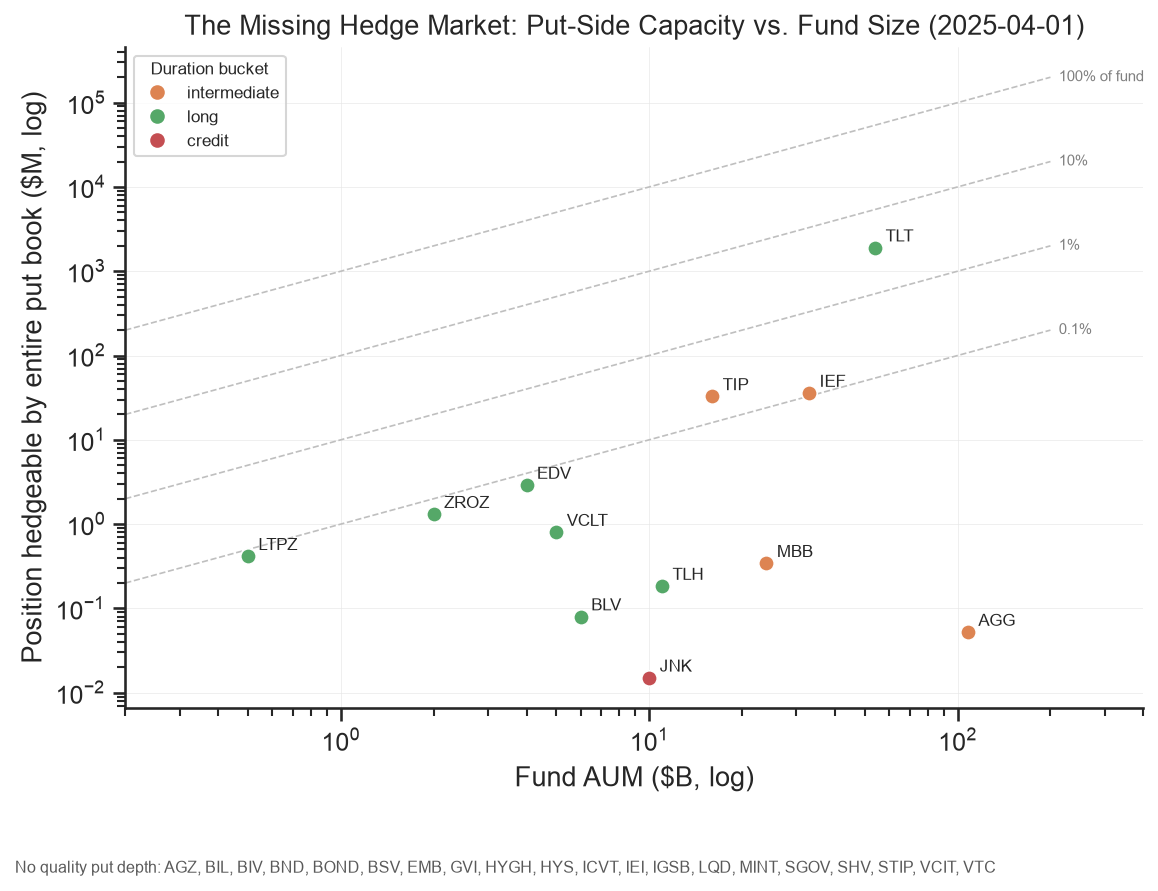

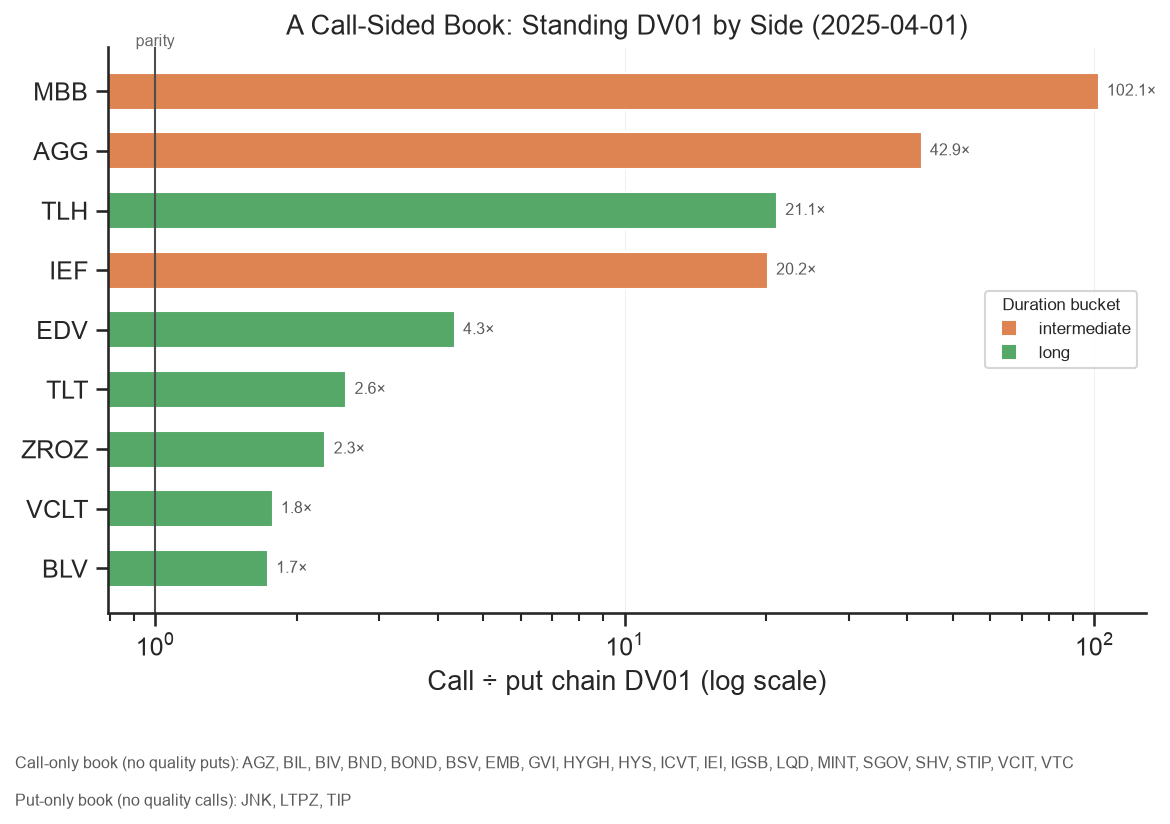

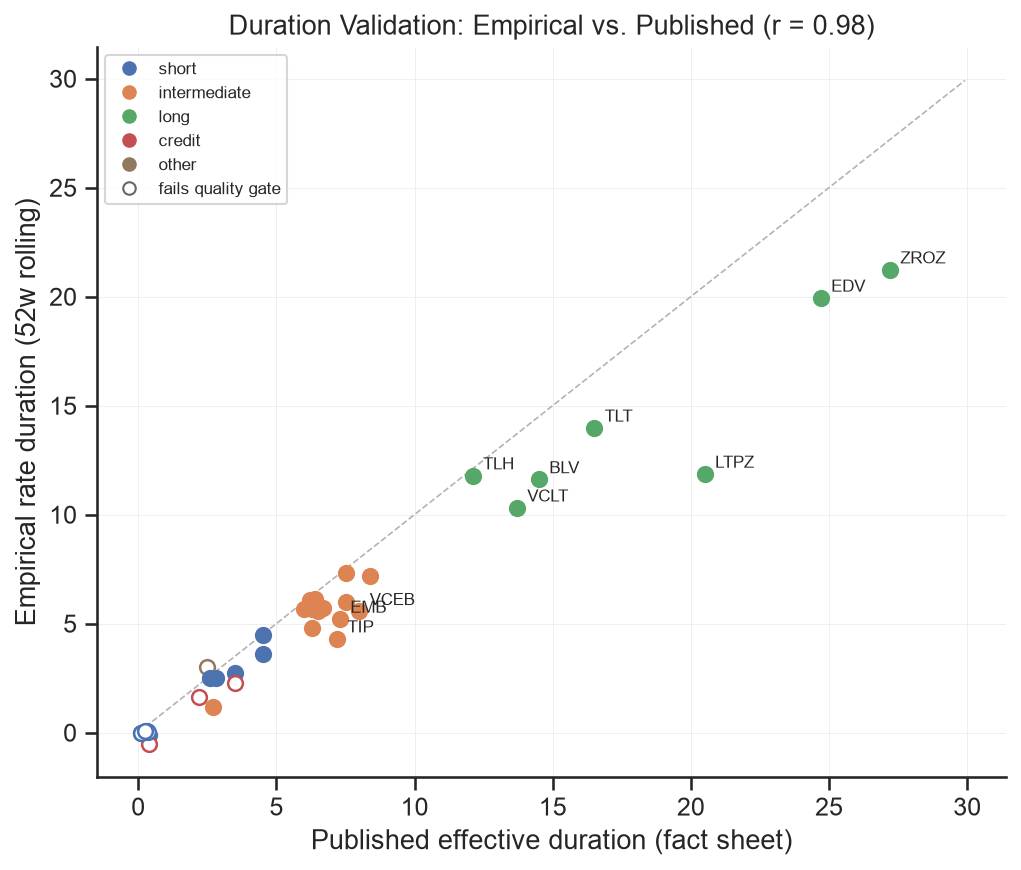

In [32]:
# ── Paper figures (read-only) — produced by scripts/07_paper_artifacts.py ─
from IPython.display import Image, display as idisplay
for f in ["24_missing_market.png", "25_call_put_ratio.png", "26_duration_validation.png"]:
    p = cfg.FIGURES_DIR / f
    if p.exists():
        idisplay(Image(filename=str(p)))
    else:
        print(f"{f} absent — run scripts/07_paper_artifacts.py")